In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import OneHotEncoder
import scipy.stats as ss
from pandas.api.types import CategoricalDtype
from dython.nominal import associations
from scipy.stats import chi2_contingency
from scipy.stats import f_oneway
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import scale
from sklearn.svm import SVC,LinearSVC
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline



<h1>Preprocesamiento<h1>

In [3]:
df_original = pd.read_csv('train.csv')
df_prepocesado = df_original.copy()
df = df_original.copy()

In [4]:
df_original.head()

,Patient_ID,BMI,Smoking,AlcoholDrinking,Stroke,PhysicalHealth,MentalHealth,DiffWalking,Sex,AgeCategory,Race,Diabetic,PhysicalActivity,GenHealth,SleepTime,Asthma,KidneyDisease,SkinCancer,HeartDisease
0,Patient_118020,45.61,Yes,No,No,0.0,0.0,No,Male,35-39,White,No,Yes,Good,360 min,No,No,No,No
1,Patient_196414,37.59,Yes,No,No,7.0,20.0,No,Female,30-34,Hispanic,No,Yes,Very good,480 min,No,No,No,No
2,Patient_107743,19.37,Yes,No,No,0.0,0.0,No,Female,50-54,White,No,Yes,Good,2 hrs,No,No,No,No
3,Patient_28303,48.42,No,No,No,30.0,15.0,No,Female,30-34,White,No,Yes,Fair,8 hrs,No,No,No,No
4,Patient_118489,27.12,No,No,No,0.0,5.0,No,Male,65-69,White,No,Yes,Very good,360 min,Yes,No,No,No


In [5]:
df_original.describe()

,BMI,PhysicalHealth,MentalHealth
count,223856.000000,223856.000000,223856.000000
mean,28.319006,3.365561,3.887763
std,6.351305,7.934696,7.948452
min,12.020000,0.000000,0.000000
25%,24.030000,0.000000,0.000000
50%,27.320000,0.000000,0.000000
75%,31.400000,2.000000,3.000000
max,94.850000,30.000000,30.000000


Eliminar el id del dataset

In [7]:
df_prepocesado = df_prepocesado.drop('Patient_ID', axis=1)

Reemplazar el SleepTime por minutos

In [6]:
df_prepocesado['SleepTime'] = df_prepocesado['SleepTime'].astype(str)
df_prepocesado["SleepTime"] = df_prepocesado['SleepTime'].str.replace(' hrs', '')

def conversion_horas(value):
  if 'min' in value:
    minutos = int(value.replace(' min', ''))
    horas = minutos / 60
    return horas
  else:
    return value

df_prepocesado['SleepTime'] = df_prepocesado["SleepTime"].apply(conversion_horas)
df_prepocesado['SleepTime'] = df_prepocesado['SleepTime'].astype(float)
df_prepocesado['SleepTime'] = df_prepocesado['SleepTime'] / 24
df_prepocesado.head(15)
df_original

,Patient_ID,BMI,Smoking,AlcoholDrinking,Stroke,PhysicalHealth,MentalHealth,DiffWalking,Sex,AgeCategory,Race,Diabetic,PhysicalActivity,GenHealth,SleepTime,Asthma,KidneyDisease,SkinCancer,HeartDisease
0,Patient_118020,45.61,Yes,No,No,0.0,0.0,No,Male,35-39,White,No,Yes,Good,360 min,No,No,No,No
1,Patient_196414,37.59,Yes,No,No,7.0,20.0,No,Female,30-34,Hispanic,No,Yes,Very good,480 min,No,No,No,No
2,Patient_107743,19.37,Yes,No,No,0.0,0.0,No,Female,50-54,White,No,Yes,Good,2 hrs,No,No,No,No
3,Patient_28303,48.42,No,No,No,30.0,15.0,No,Female,30-34,White,No,Yes,Fair,8 hrs,No,No,No,No
4,Patient_118489,27.12,No,No,No,0.0,5.0,No,Male,65-69,White,No,Yes,Very good,360 min,Yes,No,No,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
223851,Patient_153509,36.50,Yes,No,No,0.0,0.0,Yes,Male,70-74,White,Yes,Yes,Good,8 hrs,No,No,No,Yes
223852,Patient_48901,30.81,No,No,Yes,0.0,0.0,No,Male,45-49,Black,Yes,Yes,Good,480 min,Yes,Yes,No,No
223853,Patient_305860,25.12,Yes,No,No,0.0,0.0,Yes,Male,70-74,Black,No,Yes,Good,6 hrs,No,No,No,No
223854,Patient_252244,31.47,No,No,No,0.0,0.0,No,Female,60-64,White,No,Yes,Good,9 hrs,No,No,No,No


Escalar los datos numerico y categoricos


In [7]:
scaler = StandardScaler()
numeric_features = ['BMI', 'PhysicalHealth', 'MentalHealth', 'SleepTime']
df_prepocesado[numeric_features] = scaler.fit_transform(df_prepocesado[numeric_features])

Reemplazar los datos categoricos mediante el ordinal encoder

In [8]:
enc = OrdinalEncoder()
categorical_features = [ 'Smoking', 'AlcoholDrinking', 'Stroke',
        'DiffWalking', 'Sex', 'AgeCategory',
       'Race', 'Diabetic', 'PhysicalActivity', 'GenHealth',
       'Asthma', 'KidneyDisease', 'SkinCancer', 'HeartDisease']
enc.fit(df_prepocesado[categorical_features])
df_prepocesado[categorical_features] = enc.transform(df_prepocesado[categorical_features])

Revisar si hay datos vacios 

In [9]:
df_prepocesado[df_prepocesado.isnull().any(axis=1)]

,Patient_ID,BMI,Smoking,AlcoholDrinking,Stroke,PhysicalHealth,MentalHealth,DiffWalking,Sex,AgeCategory,Race,Diabetic,PhysicalActivity,GenHealth,SleepTime,Asthma,KidneyDisease,SkinCancer,HeartDisease


<h1>Analisis demografico<h1>

Text(0.5, 1.0, 'Race Count')

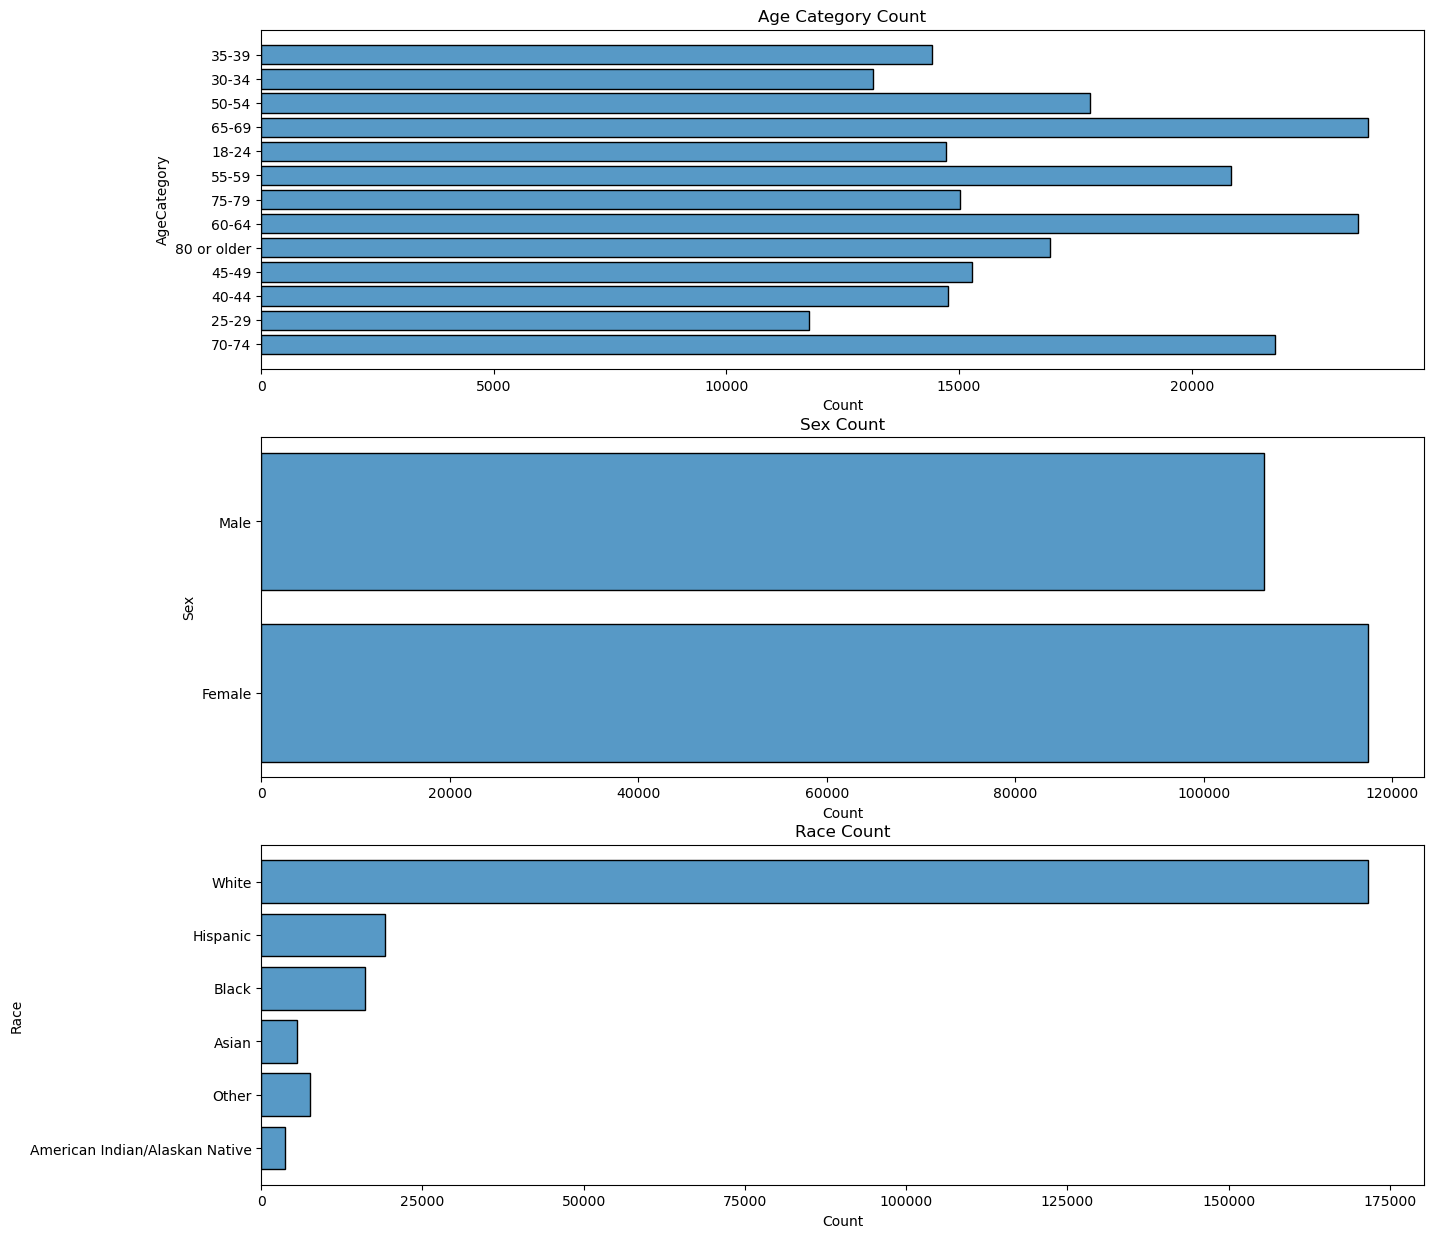

In [10]:
fig, ax = plt.subplots(3, 1, figsize=(15, 15))


sns.histplot(data=df, y="AgeCategory", shrink=.8, ax=ax[0])
ax[0].set_title('Age Category Count')

sns.histplot(data=df, y="Sex", shrink=.8, ax=ax[1])
ax[1].set_title('Sex Count')

sns.histplot(data=df, y="Race", shrink=.8, ax=ax[2])
ax[2].set_title('Race Count')



In [15]:
print(sorted(df['AgeCategory'].unique()))

['18-24', '25-29', '30-34', '35-39', '40-44', '45-49', '50-54', '55-59', '60-64', '65-69', '70-74', '75-79', '80 or older']


In [11]:
df['AgeCategory'] = pd.Categorical(df['AgeCategory'],
['18-24', '25-29', '30-34', '35-39', '40-44', '45-49', '50-54', '55-59', '60-64', '65-69', '70-74', '75-79', '80 or older']
)

<Axes: xlabel='Count', ylabel='Race'>

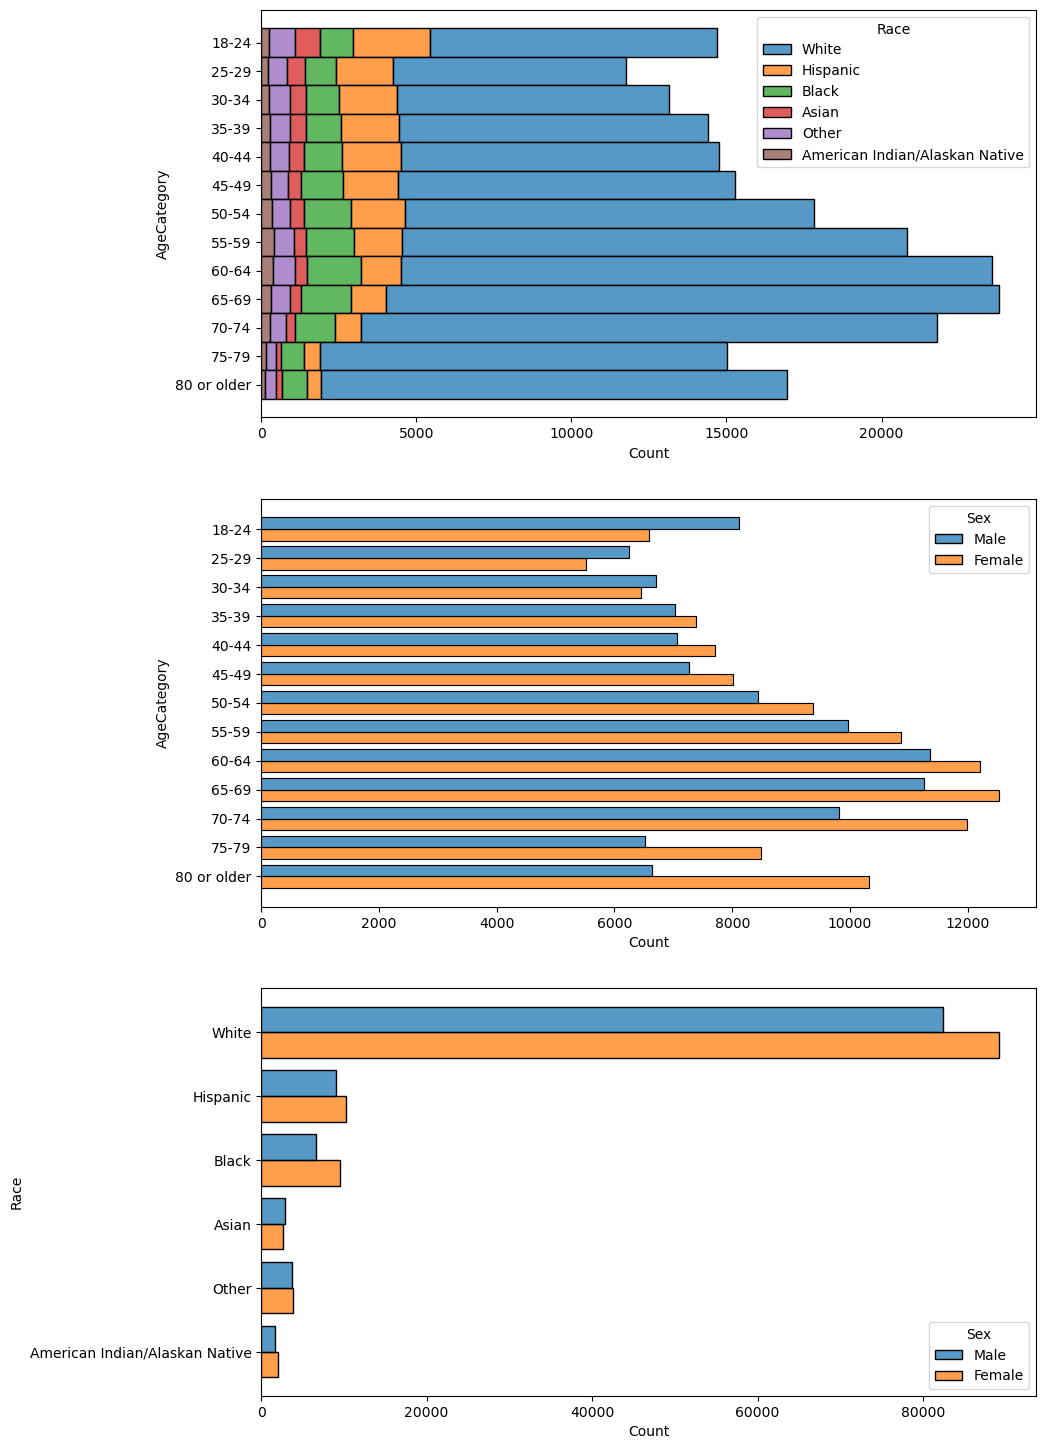

In [25]:
fig, ax = plt.subplots(3, 1, figsize=(10, 18))

sns.histplot(df, y="AgeCategory",hue='Race', multiple='stack', ax=ax[0])
sns.histplot(df, y="AgeCategory",hue='Sex',  multiple="dodge", shrink=.8,  ax=ax[1]
            )
sns.histplot(df, y="Race",hue='Sex', multiple="dodge", shrink=.8, ax=ax[2])

In [18]:
df[['AgeCategory', 'Sex', 'Race']].mode()

,AgeCategory,Sex,Race
0,65-69,Female,White


<h3>- Identificar las características demográficas más comunes entre los pacientes.</h3>
R: La mayoria son mujeres blancas de 65-69 años

<h1>Análisis de Actividad Física y Estado de Salud</h1>

<h3>- Investigar la relación entre la actividad física y el estado de salud de los pacientes.</h3>


In [19]:
category_values = ['Good', 'Very good',  'Excellent', 'Fair','Poor']
category_order = CategoricalDtype(category_values, ordered=True)
df['GenHealth']= df['GenHealth'].astype(category_order)


<Axes: xlabel='PhysicalActivity', ylabel='Count'>

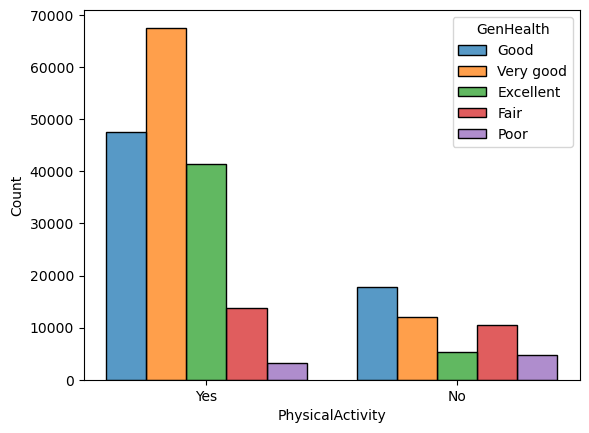

In [20]:
sns.histplot(df, x="PhysicalActivity",hue='GenHealth', multiple="dodge", shrink=.8)



Funcion para obtener la correlacion mediante el metodo de Cramers

In [22]:

def cramers_v(x, y):
    confusion_matrix = pd.crosstab(df[x],df[y])
    chi2 = ss.chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    phi2 = chi2/n
    r,k = confusion_matrix.shape
    phi2corr = max(0, phi2-((k-1)*(r-1))/(n-1))
    rcorr = r-((r-1)**2)/(n-1)
    kcorr = k-((k-1)**2)/(n-1)
    res = np.sqrt(phi2corr/min((kcorr-1),(rcorr-1)))
    print('La correlacion entre ', x, 'y ', y, 'es: ' , res)


cramers_v('PhysicalActivity', 'GenHealth')


La correlacion entre  PhysicalActivity y  GenHealth es:  0.29339857433860556


<h3>Conclusion</h3>
R: Entre mayor actividad fisica es mejor su estado de salud

<h3>Determinar cómo la actividad física y su dificultad para caminar (DiffWalking) se
correlaciona con indicadores de salud como el índice de masa corporal (BMI), la salud física y
mental, y la prevalencia de enfermedades crónicas.
</h3>

In [25]:
def get_anova(col_categorica, col_continua):

    # Running the one-way anova test between CarPrice and FuelTypes
    # Assumption(H0) is that FuelType and CarPrices are NOT correlated

    CategoryGroupLists=df.groupby(col_categorica)[col_continua].apply(list)

    # Performing the ANOVA test
    # We accept the Assumption(H0) only when P-Value &gt> 0.05
    AnovaResults = f_oneway(*CategoryGroupLists)
    print('P-Value for Anova is: ', AnovaResults[1])


Correlaciones en grafica de violin entre Actividad fisica, diffwalking y (BMI), la salud física y
mental, y la prevalencia de enfermedades crónicas.


La correlacion entre  PhysicalActivity y  BMI es:  0.19336706448400778
La correlacion entre  DiffWalking y  BMI es:  0.23477670858784697


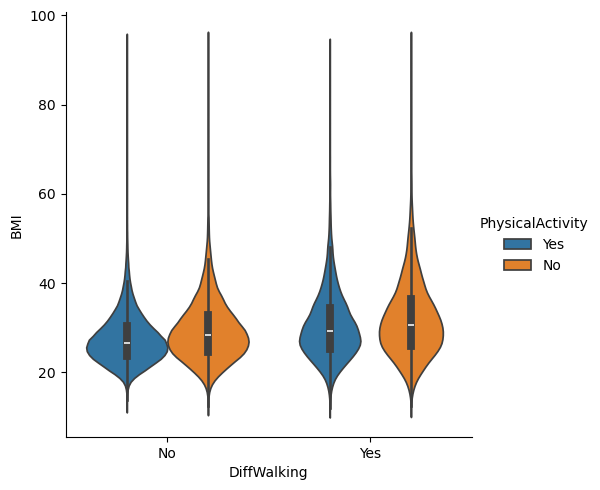

In [26]:

cramers_v('PhysicalActivity', 'BMI')
cramers_v('DiffWalking', 'BMI')
sns.catplot(df, hue="PhysicalActivity",x='DiffWalking', y='BMI', kind='violin')

La correlacion entre  PhysicalActivity y  PhysicalHealth es:  0.2307853040971636
La correlacion entre  DiffWalking y  PhysicalHealth es:  0.433347745651503


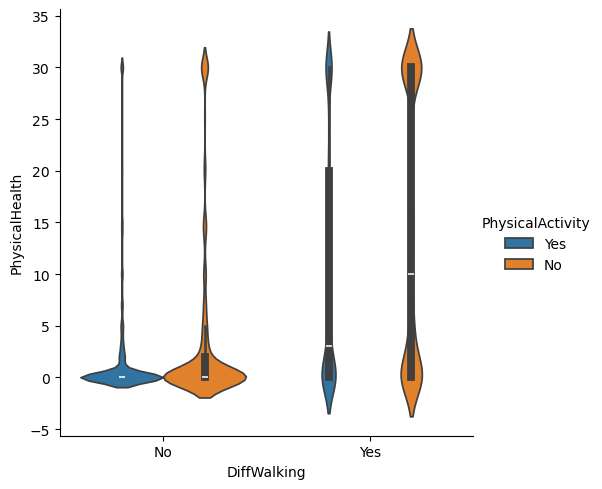

In [27]:
cramers_v('PhysicalActivity', 'PhysicalHealth')
cramers_v('DiffWalking', 'PhysicalHealth')
sns.catplot(df, hue="PhysicalActivity",x='DiffWalking', y='PhysicalHealth', kind='violin')


La correlacion entre  PhysicalActivity y  MentalHealth es:  0.1138670370968151
La correlacion entre  DiffWalking y  MentalHealth es:  0.15474866649873337


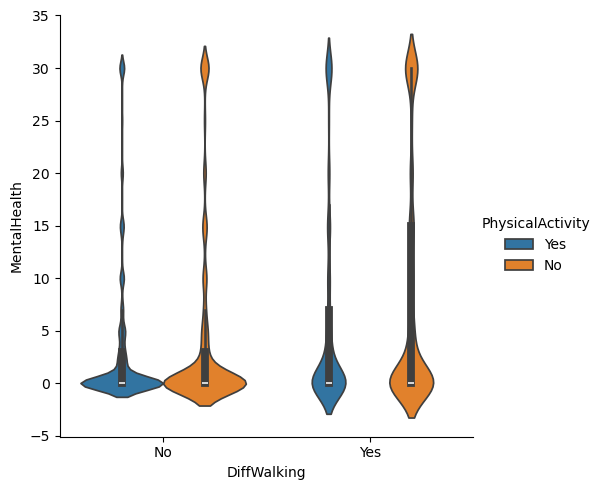

In [28]:
cramers_v('PhysicalActivity', 'MentalHealth')
cramers_v('DiffWalking', 'MentalHealth')
sns.catplot(df, hue="PhysicalActivity",x='DiffWalking', y='MentalHealth', kind='violin')

La correlacion entre  PhysicalActivity y  Asthma es:  0.04054079375126068
La correlacion entre  DiffWalking y  Asthma es:  0.10372423230749543


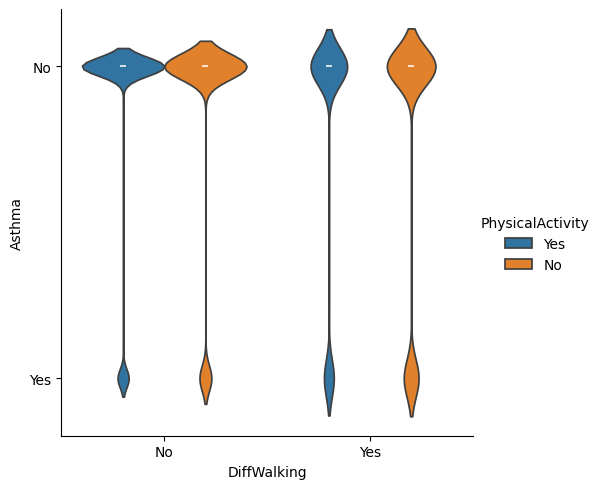

In [29]:
cramers_v('PhysicalActivity', 'Asthma')
cramers_v('DiffWalking', 'Asthma')
sns.catplot(df, hue="PhysicalActivity",x='DiffWalking', y='Asthma', kind='violin')

La correlacion entre  PhysicalActivity y  KidneyDisease es:  0.08115576215380074
La correlacion entre  DiffWalking y  KidneyDisease es:  0.15047285824946655


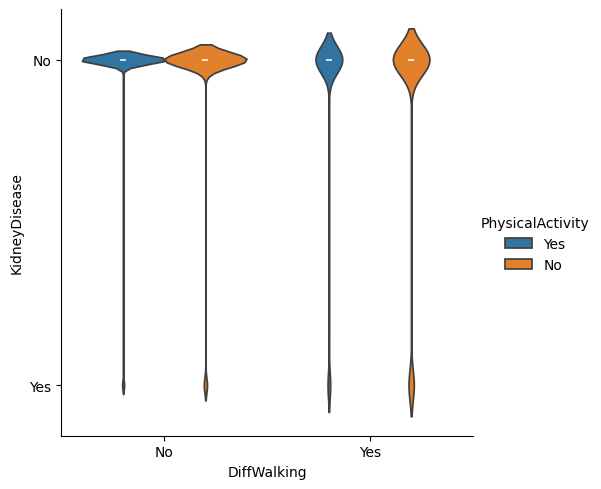

In [30]:
cramers_v('PhysicalActivity', 'KidneyDisease')
cramers_v('DiffWalking', 'KidneyDisease')
sns.catplot(df, hue="PhysicalActivity",x='DiffWalking', y='KidneyDisease', kind='violin')

La correlacion entre  PhysicalActivity y  SkinCancer es:  0.0
La correlacion entre  DiffWalking y  SkinCancer es:  0.06401495174349252


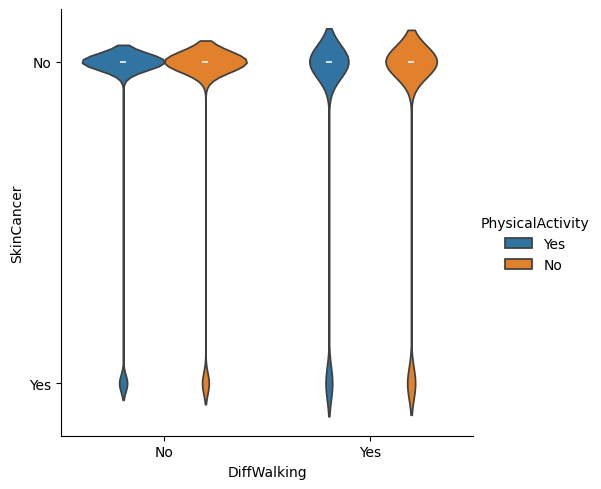

In [31]:
cramers_v('PhysicalActivity', 'SkinCancer')
cramers_v('DiffWalking', 'SkinCancer')
sns.catplot(df, hue="PhysicalActivity",x='DiffWalking', y='SkinCancer', kind='violin')

La correlacion entre  PhysicalActivity y  HeartDisease es:  0.09988254701515828
La correlacion entre  DiffWalking y  HeartDisease es:  0.20039596276147312


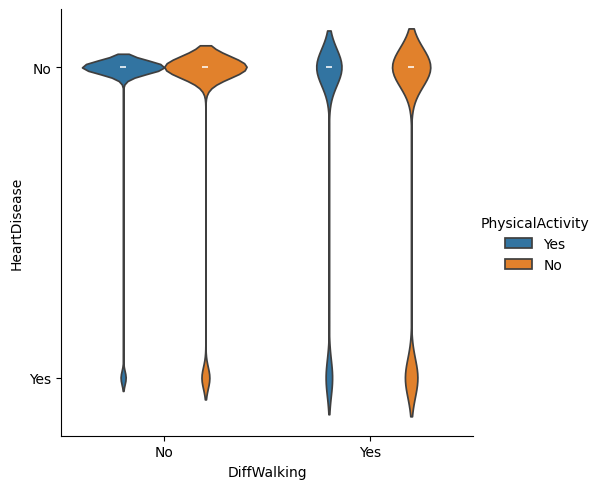

In [32]:
cramers_v('PhysicalActivity', 'HeartDisease')
cramers_v('DiffWalking', 'HeartDisease')
sns.catplot(df, hue="PhysicalActivity",x='DiffWalking', y='HeartDisease', kind='violin')

La correlacion entre  PhysicalActivity y  Diabetic es:  0.14308010212906763
La correlacion entre  DiffWalking y  Diabetic es:  0.21820482770288605


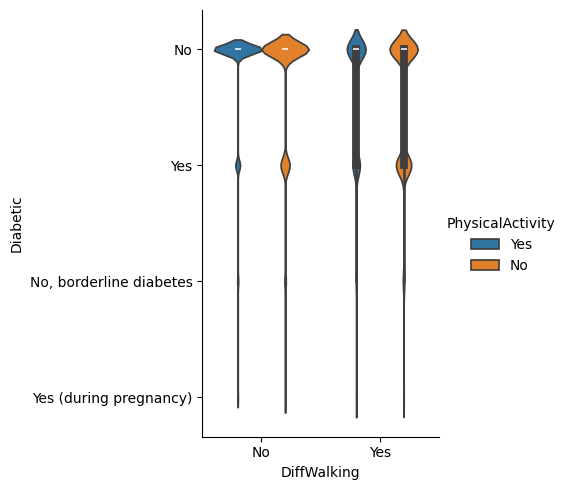

In [33]:
cramers_v('PhysicalActivity', 'Diabetic')
cramers_v('DiffWalking', 'Diabetic')
sns.catplot(df, hue="PhysicalActivity",x='DiffWalking', y='Diabetic', kind='violin')

<h3>Tabla de correlaciones</h3>

c:\Users\Tauro\anaconda3\Lib\site-packages\dython\nominal.py:736: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  inf_nan.loc[columns[i], columns[j]] = _inf_nan_str(ij)
c:\Users\Tauro\anaconda3\Lib\site-packages\dython\nominal.py:737: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  inf_nan.loc[columns[j], columns[i]] = _inf_nan_str(ji)


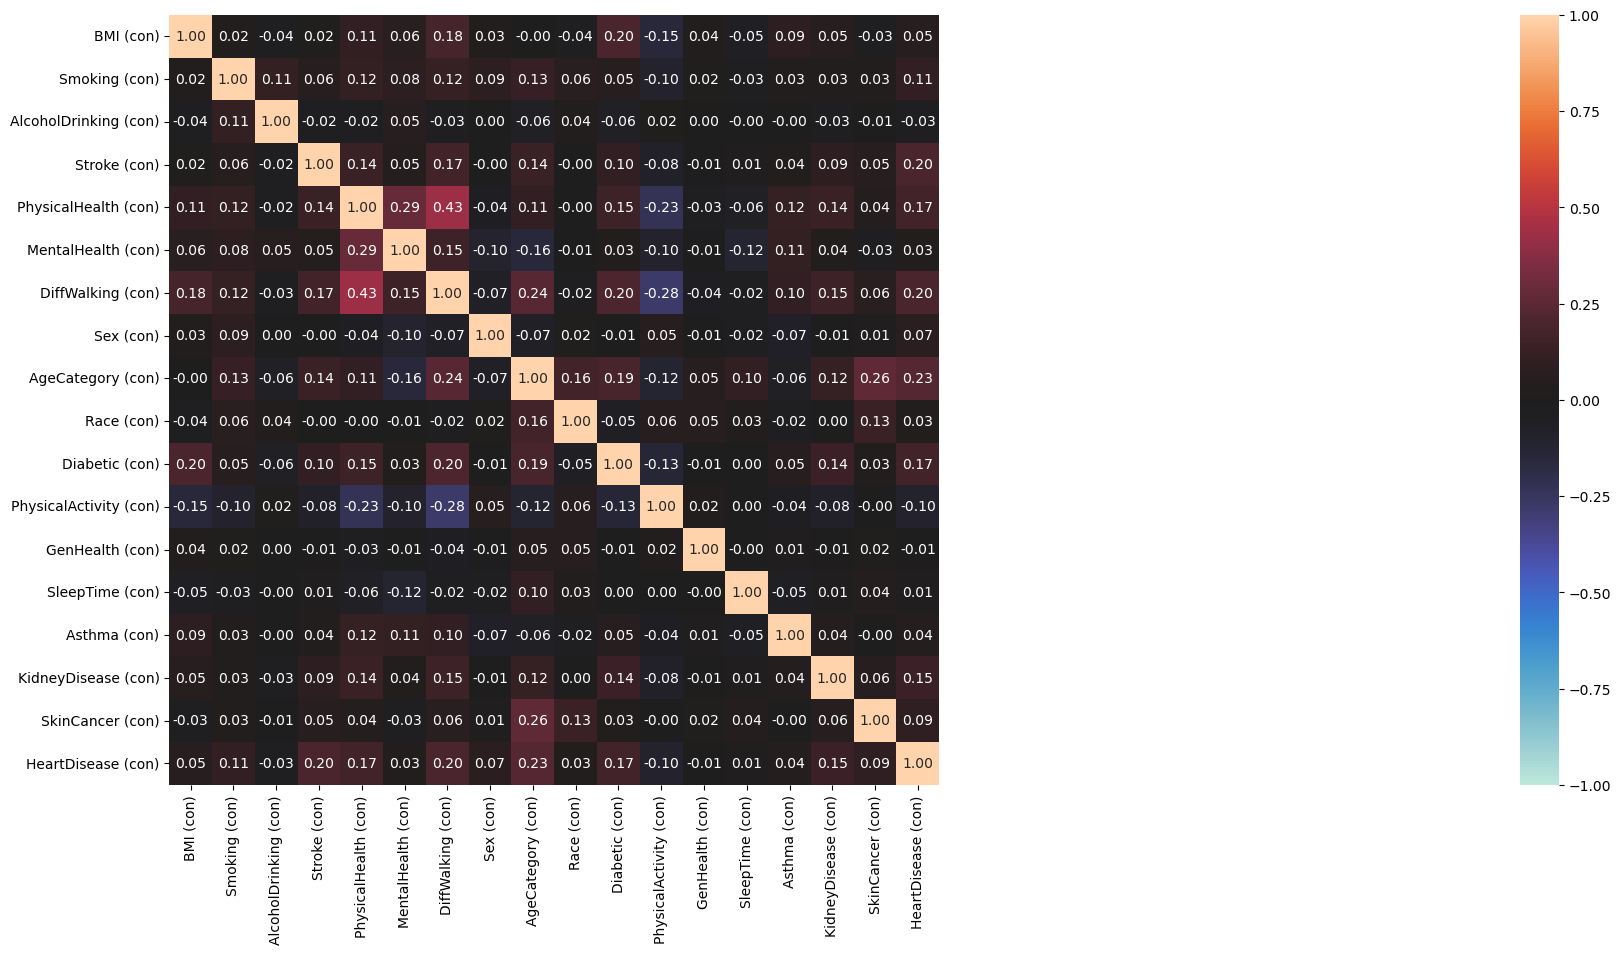

{'corr':                         BMI (con)  Smoking (con)  AlcoholDrinking (con)  \
 BMI (con)                1.000000       0.023871              -0.038314   
 Smoking (con)            0.023871       1.000000               0.112849   
 AlcoholDrinking (con)   -0.038314       0.112849               1.000000   
 Stroke (con)             0.018832       0.061279              -0.018671   
 PhysicalHealth (con)     0.108828       0.115456              -0.016254   
 MentalHealth (con)       0.064941       0.084935               0.053233   
 DiffWalking (con)        0.181616       0.121230              -0.032809   
 Sex (con)                0.027180       0.086538               0.004202   
 AgeCategory (con)       -0.004796       0.127959              -0.061437   
 Race (con)              -0.038117       0.064730               0.035516   
 Diabetic (con)           0.202953       0.054058              -0.058401   
 PhysicalActivity (con)  -0.152546      -0.097665               0.015837   
 Gen

In [34]:
columnas_correlaciones = [ 'PhysicalActivity',
                          'DiffWalking',
                          'BMI',
                          'PhysicalHealth',
                          'MentalHealth',
                          'Asthma',
                          'KidneyDisease',
                          'SkinCancer',
                          'HeartDisease',
                          'Diabetic',
                          ]

df_prepocesado2 = df_prepocesado
associations(df_prepocesado2,figsize=(150, 10),
            #  nominal_columns='all',
            #  numerical_columns=['BMI, PhysicalHealth, MentalHealth'],
             mark_columns=True)

<h3>Conclusion</h3>
R: Se encontro que hay una correlacion entre el Diffwalking, y la diabetes y las enfermedades del corazon

<h3>Explorar cualquier asociación entre la actividad física y la presencia de condiciones crónicas
como enfermedades cardíacas o diabetes en el conjunto de datos.</h3>

La correlacion entre  PhysicalActivity y  Diabetic es:  0.14308010212906763
La correlacion entre  PhysicalActivity y  HeartDisease es:  0.09988254701515828
La correlacion entre  PhysicalActivity y  SkinCancer es:  0.0
La correlacion entre  PhysicalActivity y  KidneyDisease es:  0.08115576215380074
La correlacion entre  PhysicalActivity y  Asthma es:  0.04054079375126068
La correlacion entre  PhysicalActivity y  Stroke es:  0.07928823149278375


<Axes: xlabel='PhysicalActivity', ylabel='Count'>

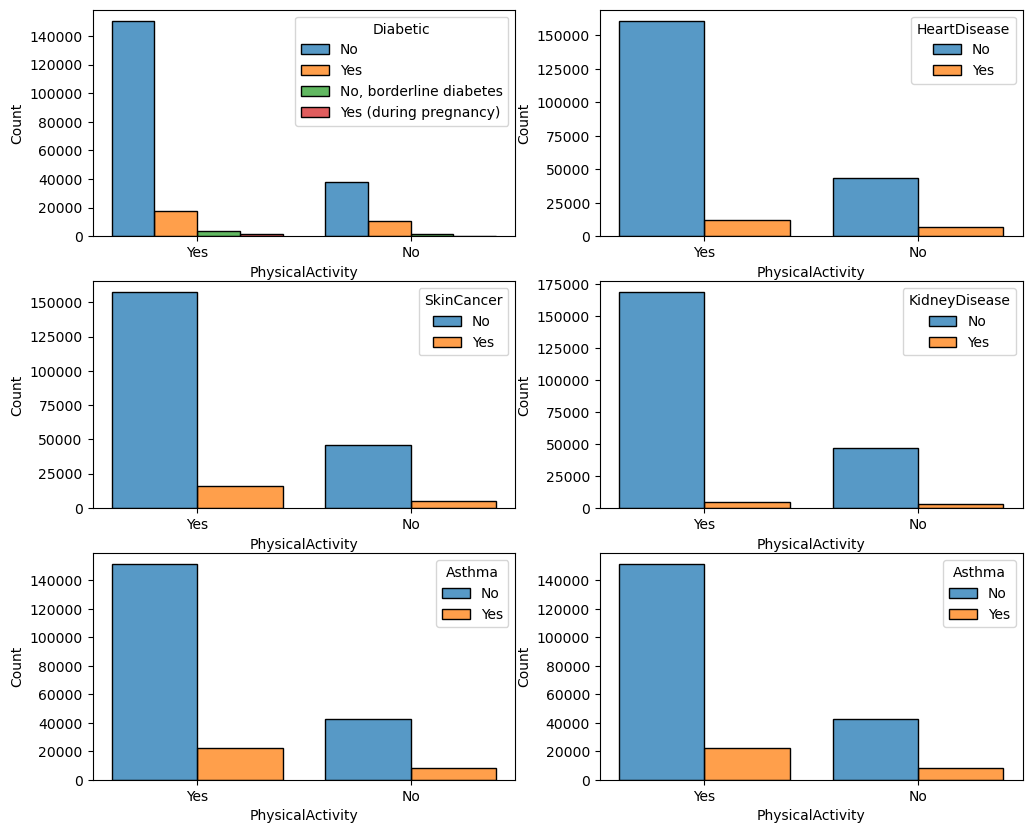

In [35]:
fig, ax = plt.subplots(3, 2, figsize=(12,10))

cramers_v('PhysicalActivity', 'Diabetic')
sns.histplot(df, x="PhysicalActivity",hue='Diabetic', multiple="dodge", shrink=.8 ,ax=ax[0,0])

cramers_v('PhysicalActivity', 'HeartDisease')
sns.histplot(df, x="PhysicalActivity",hue='HeartDisease',multiple="dodge", shrink=.8, ax=ax[0,1])

cramers_v('PhysicalActivity', 'SkinCancer')
sns.histplot(df, x="PhysicalActivity",hue='SkinCancer',multiple="dodge", shrink=.8, ax=ax[1,0])

cramers_v('PhysicalActivity', 'KidneyDisease')
sns.histplot(df, x="PhysicalActivity",hue='KidneyDisease',multiple="dodge", shrink=.8, ax=ax[1,1])

cramers_v('PhysicalActivity', 'Asthma')
sns.histplot(df, x="PhysicalActivity",hue='Asthma',multiple="dodge", shrink=.8, ax=ax[2,0])

cramers_v('PhysicalActivity', 'Stroke')
sns.histplot(df, x="PhysicalActivity",hue='Asthma',multiple="dodge", shrink=.8, ax=ax[2,1])


<h3>Conclusion:</h3>
R: Entre mayor actividad Fisica, menor probabilidad hay de obtener enfermedades cronicas

<h1>Modelo ML</h1>

Se hace el train test split de los datos


In [36]:
# Muestreo estratificado del 10% del dataset original
# stratify_df, _ = train_test_split(df_prepocesado, test_size=0.9, stratify=df['HeartDisease'], random_state=42)

y = df_prepocesado['HeartDisease']
X = df_prepocesado.drop(['HeartDisease'], axis=1)

# Dividir el conjunto de datos en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)


Se uso el modelo de Linear SVC con Grid Search para la creacion del modelo

In [37]:

param_grid = {'C': [0.1, 1, 10,  1000],
              'gamma': [1, 0.1, 0.01,  0.0001],
              'kernel': ['linear']}

SVCpipe = Pipeline([('scale', StandardScaler()),
                   ('SVC',LinearSVC())])

# Gridsearch to determine the value of C
param_grid = {'SVC__C':np.arange(0.01,100,10)}
linearSVC = GridSearchCV(SVCpipe,param_grid,cv=5,return_train_score=True)
linearSVC.fit(X_train,y_train)



c:\Users\Tauro\anaconda3\Lib\site-packages\sklearn\svm\_base.py:1244: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
c:\Users\Tauro\anaconda3\Lib\site-packages\sklearn\svm\_base.py:1244: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
c:\Users\Tauro\anaconda3\Lib\site-packages\sklearn\svm\_base.py:1244: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
c:\Users\Tauro\anaconda3\Lib\site-packages\sklearn\svm\_base.py:1244: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
c:\Users\Tauro\anaconda3\Lib\site-packages\sklearn\svm\_base.py:1244: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
c:\Users\Tauro\anaconda3\Lib\site-packages\sklearn\svm\_base.py:1244: ConvergenceWarning: Liblinear failed to converge, increase the number 

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('scale', StandardScaler()),
                                       ('SVC', LinearSVC())]),
             param_grid={'SVC__C': array([1.000e-02, 1.001e+01, 2.001e+01, 3.001e+01, 4.001e+01, 5.001e+01,
       6.001e+01, 7.001e+01, 8.001e+01, 9.001e+01])},
             return_train_score=True)

In [38]:
print(linearSVC.best_params_)


bestlinearSVC = linearSVC.best_estimator_
bestlinearSVC.fit(X_train,y_train)
bestlinearSVC.coef_ = bestlinearSVC.named_steps['SVC'].coef_
bestlinearSVC.score(X_train,y_train)

{'SVC__C': 0.01}


0.9151175182994148

Matrix de confusion si entre lo predicho  y lo que venia marcado en el dataset acerca de si es propenso a tener enfermedades del corazon

Accuracy: 91.60%


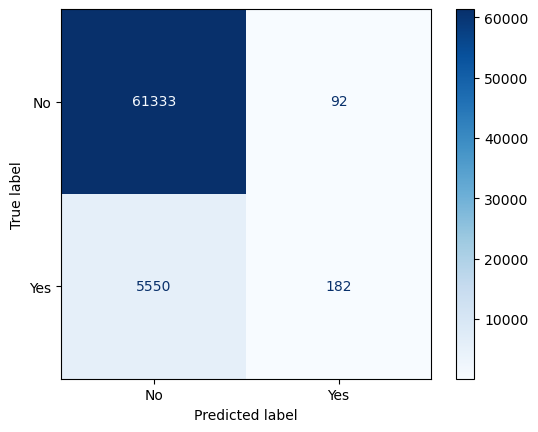

In [39]:
y_pred = linearSVC.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy:.2%}')

class_names = ['No','Yes']
disp = ConfusionMatrixDisplay.from_estimator(
        linearSVC,
        X_test,
        y_test,
        display_labels=class_names,
        cmap=plt.cm.Blues)